# Ochlazování tělesa  

Uvažujme těleso, které předává teplo do svého okolí, čímž dochází k jeho ochlazování.
V časech $t_k = k\Delta$ pro $k=0, 1, \ldots, n$, kde $\Delta>0$ je konstantní délka intervalu mezi jednotlivými měřeními, měříme teplotu tělesa, přičemž jednotlivá měření, označená jako $y_k$, jsou zatížena náhodnou chybou. Na základě měření $y_0, y_1, \ldots, y_k$ budeme průběžně odhadovat aktuální teplotu $x_k$.
 
## Model systém
V idealizovném případě je ochalzování tělesa popsáno tzv. Newtonovým zákonem ochlazování.
Teplotu tělesa jakožto funkci (spojitého) času označme $x(t)$. 
Podle Newtonova zákona ochlazování odpovídá teplota tělesa v čase $t$ řešení lineární diferenciální rovnice prvního řádu s počáteční podmínkou

\begin{align}
x'(t)&=-q(x(t)-T_{ok}),\\
x(0)&=T_0.
\end{align}
kde
<ul>
    <li>$q>0$ je známý konstantní koeficient přestupu tepla,</li>
    <li>$T_{ok}$ je známá konstantní teplota okolí,</li>
    <li>$T_0$ je známá teplota v čase $t=0$.</li>
</ul> 

Výše popsaná počáteční úloha vychází z předpokladů, jejichž splnění lze ve skutečnosti těžko očekávat.
Úlohu upravíme tak, aby lépe popisovala reálnou situaci.

<ul>
    <li>Na teplotu tělesa působí další vlivy, které budeme reprezentovat jako malé náhodné výchylky.</li>
    <li>Hodnota koeficientu $q$ závisí na mnoha faktorech, jako např. velikost povrchu tělesa, 
        materiál povrchu, proudění vzduchu v okolí tělesa apod. V reálné úloze je prakticky 
        nemožné tento koeficient s dostatečnou přesností určit teoreticky. Často lze ale na základě 
        zkušenosti s podobnou situací koeficient alespoň přibližně odhadnout. </li>  
    <li>Hodnota koeficientu $q$ se může v čase měnit v závislosti na změnách okolních podmínek. Protože tyto změny nejsme schopni modelovat, zahrneme je do modelu rovněž jako malé náhodné výchylky.</li> 
    <li>Počáteční teplota $T_{0}$ před začátkem měření není známá.</li>
</ul>    

Koeficient $q$ budeme nejprve uvažovat jako funkci času. V modelu bez vlivu náhodných složek bude koeficient reprezentován konstantní funkcí času $q(t)$. Model systému pak mude mít podobu nelineární soustavy rovnic prvního řádu

\begin{align}
x'(t) &=-q(t)(x(t)-T_{ok}),\\
q'(t) &= 0.
\end{align}

## Diskretizace
Diskretizaci provedeme pomocí Eulerovy metody, čímž dostaneme nelineární soustavu diferenčních rovnic

\begin{align}
x_k &=x_{k-1}-\Delta q_{k-1}(x_{k-1}-T_{ok}),\\
q_k &=q_{k-1}.
\end{align}

Označme stavový vektor jako $X_k$, tj. $X_k=(x_k, q_k)$. Model systému pak můžeme zapsat vektorově jako 

$$X_k = f(X_{k-1}),$$
kde 
$$f(x, q) = (x-\Delta q(x-T_{ok}),q).$$

## Rozšíření modelu o náhodné vlivy
Náhodné změny teploty a koeficientu ochlazování modelujeme jako náhodné vektory 
$$W_k\sim \mathcal N((0, 0), Q),$$
kde 
$$Q=\begin{pmatrix}
\sigma_x^2 & 0 \\
0 & \sigma_q^2 
\end{pmatrix}.$$

Vhodnou hodnotu $\sigma_x^2$ může zvolit na základě náseldující úvahy. Celkový pokles teploty za celou dobu měření je přibižně 20 stupňů. Pokud by směrodatná odchylka součtu náhodných příspěvků dosahovala 1 $^\circ$C, tj. s pravděpodobností přibližně 0.95 by se součet náhodných odchylek pohyboval přibližně v intervalu -/+ 2 $^\circ$C (desetina celkového poklesu), bude $\sigma_x^2$ rovna přibližně  $1.4\cdot 10^{-3}$. (Rozptyl součtu nezávislýh náhodných veličin je roven součtu jejich rozptylů. Doba mezi měřeními je 0.03 minuty. Za 22 minut dosahuje rozptyl součtu náhodných chyb hodnoty 1.02 $^\circ$C.)

Podobnou úvahou dojdeme k hodnotě $\sigma_q^2$. Prvotní odhad parametru $q$ je dosahuje přibližně hodnoty 0.025. Pokud bychom opět předpokládali směrodatnou odchylku součtu náhodných příspěvků odpovídající 5 % z 0.025, dojdeme k $\sigma_q^2=2.1\cdot 10^{-9}$.

Stochastický model systému tak má podobu

\begin{align}
X_k &= f(X_{k-1}) + W_k,\\
\end{align}
kde
\begin{align}
f(x, q) &= (x-\Delta q(x-T_{ok}),q),\\
W_k &\sim \mathcal N((0, 0), Q),\\
Q &=\begin{pmatrix}
1.4\cdot 10^{-3} & 0 \\
0 & 2.1\cdot 10^{-9}
\end{pmatrix}.\\
\end{align}

## Model pozorování
Měření $Y_k$ odpovídají přímo teplotám $x_k$ zatíženým aditivní gaussovskou chybou, tj.
\begin{align}
Y_k &= GX_k+V_k,\\
G &= (1, 0),\\
V_k &\sim \mathcal N(0, 10^{-3}).\\
\end{align}
Rozptyl chyby měření lze odhadnout z krátké posloupnoti měřených hodnot, kdy se dá vývoj měřených teplot dostatečně dobře aproximovat lineární funkcí času.


In [1]:
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
# nacteni dat ze souboru
data = np.load("mereni3.npy")

In [3]:
data = data[:, 50:800] 

ts = data[0, 1:]     # casy mereni v minutach
ts = ts - data[0, 0] # pocatek mereni nastavime na t=0
ys = data[1, 1:]     # merene teploty


Text(0.5, 1.0, 'Měření')

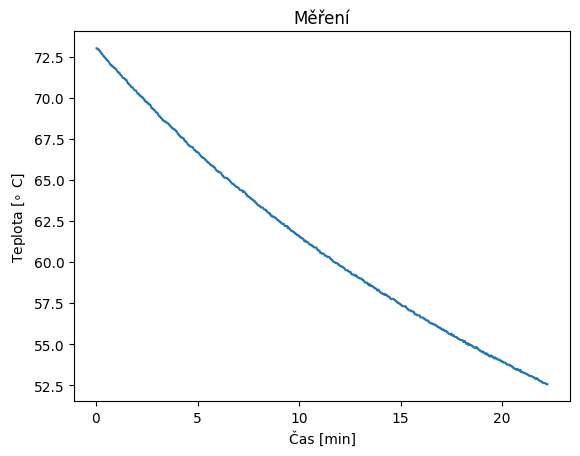

In [4]:
# graf merenych teplot
plt.figure()
plt.plot(ts, ys)
plt.xlabel('Čas [min]')
plt.ylabel('Teplota [$\\circ$ C]')
plt.title('Měření')

In [7]:
# implementace rozsireneho Kalanova filtru
class EKF:
    def __init__(self, mu0, sig0, to):
        self.trace_t = np.array([0])
        self.trace_mu = np.array([mu0,])
        self.trace_sig = np.array([sig0,])
        self.to = to
        self.k = 0
    
    def step(self, t, y):
        # krok rozsirenenho Kalmanova filtru
        self.k += 1
        
        mu_ = self.trace_mu[-1]   # \mu_{k-1}
        sig_ = self.trace_sig[-1] # \Sigma_{k-1}
        t_ = self.trace_t[-1]     # t_{k-1}
        D = t-t_                  # t_k-t_{k-1}
        
        mup = np.array([mu_[0]*(1-mu_[1]*D)+mu_[1]*self.to*D, mu_[1]])
        F = np.array([[1-mu_[1]*D, (self.to-mu_[0])*D],
                      [0, 1]])
        # kovariancni matice nahodne slozky v modelu systemu
        Q = np.array([[1.4e-3, 0], 
                      [0, 2.1e-9]])

        sigp = F@sig_@F.T+Q        
        G = np.array([[1, 0]])
        # kovariancni matice chyby mereni
        R = np.array([0.001])
        K = sigp@G.T@np.linalg.inv((G@sigp@G.T+R).reshape((1,1)))
        mu = mup+(K@((y-mup[0]).reshape((1,1)))).reshape(-1)
        sig = sigp-K@G@sigp
 
        self.trace_mu = np.append(self.trace_mu, [mu], axis=0)
        self.trace_sig = np.append(self.trace_sig, [sig], axis=0)
        self.trace_t =  np.append(self.trace_t, t)    

In [8]:
# parametry pocatecniho odhadu
mu0 = np.array([50, 0.1])          # vektor str. hodnot pocatecniho odhadu
sig0 = np.diag([20**2, 0.1**2])    # kovariancni matice pocatecniho odhadu


In [12]:
# vytvoreni rozsireneho KF
ekf = EKF(mu0, sig0, 22.7)

N = len(ys) # pocet pouzitych mereni

# vypocet filtrace
for k in range(N):
    ekf.step(ts[k], ys[k])


(50.0, 80.0)

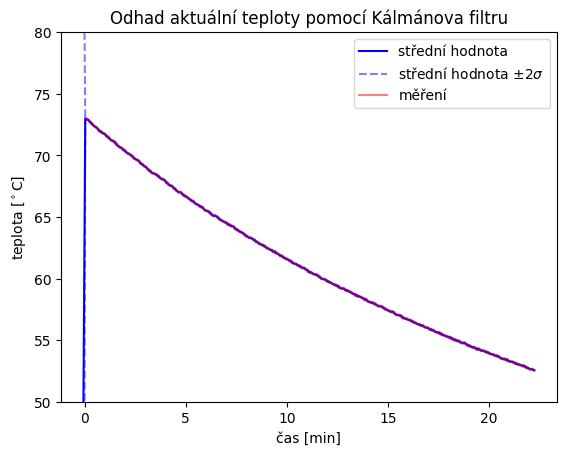

In [13]:
plt.figure()
tmus = ekf.trace_mu[:, 0]
tsigs = ekf.trace_sig[:, 0, 0]**0.5
ts_ext = np.concatenate([[-ts[1]], ts])[0:(N+1)]

plt.plot(ts_ext,tmus, 'b', label='střední hodnota')
plt.plot(ts_ext, tmus-2*tsigs, 'b--', alpha=0.5, label='střední hodnota $\\pm 2\\sigma$')
plt.plot(ts_ext, tmus+2*tsigs, 'b--', alpha=0.5)

plt.plot(ts[0:N], ys[0:N], 'r', alpha=0.5, label='měření')
plt.title('Odhad aktuální teploty pomocí Kálmánova filtru')
plt.xlabel("čas [min]")
plt.ylabel("teplota [$^\\circ$C]")
plt.legend();

plt.ylim(50, 80)

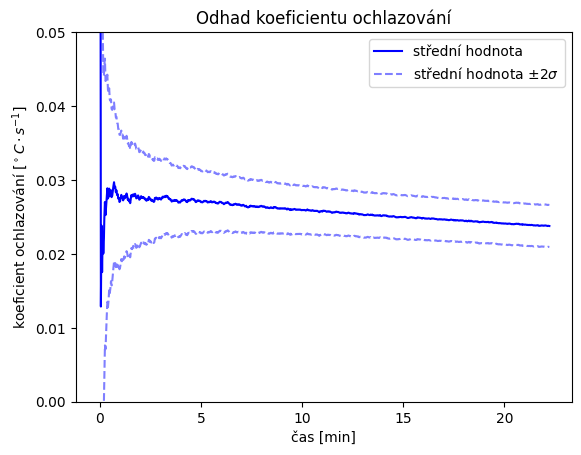

In [14]:
plt.figure()
cmus = ekf.trace_mu[:, 1]
csigs = ekf.trace_sig[:, 1, 1]**0.5
plt.plot(ts_ext, cmus, 'b', label='střední hodnota')
plt.plot(ts_ext, cmus-2*csigs, 'b--', alpha=0.5, label='střední hodnota $\\pm 2\\sigma$')
plt.plot(ts_ext, cmus+2*csigs, 'b--', alpha=0.5)
plt.title('Odhad koeficientu ochlazování')
plt.xlabel("čas [min]")
plt.ylabel("koeficient ochlazování [$^\\circ C\\cdot s^{-1}$]")
plt.ylim(0, 0.05)
plt.legend();
